In [26]:
%reload_ext autoreload
%autoreload 2

In [27]:
import numpy as np
from collections import OrderedDict

from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

design = designs.DesignPlanar()
gui = MetalGUI(design)

# if you disable the next line, then you will need to delete a component [<component>.delete()] before recreating it
design.overwrite_enabled = True

In [28]:
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround

In [29]:
Q1 = TransmonPocket6(design,'Q1',options = dict(
    pos_x = '-1.25mm',
    pos_y = '-0.5mm',
    gds_cell_name = 'Transmon_1',
    hfss_inductance = '14nH',
    orientation = '90',
    connection_pads = dict(
        bus_01 = dict(loc_W = 0, loc_H = -1, pad_width = '80um' , pad_gap = '15um'),
        port_01 = dict(loc_W = 0, loc_H = 1, pad_width = '30um' , pad_gap = '15um')
    )
))
Q2 = TransmonPocket6(design,'Q2',options = dict(
    pos_x = '1.25mm',
    pos_y = '0.5mm',
    gds_cell_name = 'Transmon_1',
    hfss_inductance = '14nH',
    orientation = '270',
    connection_pads = dict(
        bus_01 = dict(loc_W = 0, loc_H = -1, pad_width = '80um' , pad_gap = '15um'),
        port_01 = dict(loc_W = 0, loc_H = 1, pad_width = '30um' , pad_gap = '15um')
    )
))
gui.autoscale()
gui.rebuild()

In [30]:
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
LP1 = LaunchpadWirebond(
    design, 'LP_Q1',
    options=Dict(
        pos_x='-2.5mm',
        pos_y='-1.1mm',
        orientation='0'
    )
)
gui.rebuild()
gui.autoscale()

In [31]:
LP2 = LaunchpadWirebond(
    design, 'LP_Q2',
    options=Dict(
        pos_x='-3mm',
        pos_y='0mm',
        orientation='0'
    )
)
gui.rebuild()
gui.autoscale()

In [32]:
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
ops=dict(fillet='90um')
anchors_Q1 = OrderedDict()
anchors_Q1[0] = np.array([-2.5,0])
anchors_Q1[1] = np.array([-2.5,0.5])
anchors_Q1[2] = np.array([-2.5,1.5])
anchors_Q1[3] = np.array([-2.3,1.0])
anchors_Q1[4] = np.array([-2.1,1.5])
anchors_Q1[5] = np.array([-1.9,1.0])
anchors_Q1[6] = np.array([-1.7,0.6])
anchors_Q1[7] = np.array([-1.7,1.5])
anchors_Q1[8] = np.array([-1.5,0.2])
anchors_Q1[9] = np.array([-1.9,0.2])
options1 = {'pin_inputs':
            {'start_pin': {'component': 'LP_Q2', 'pin': 'tie'},
             'end_pin': {'component': 'Q1', 'pin': 'port_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q1,
            **ops
           }

qc1 = RoutePathfinder(design, 'line_Q1', options1)

gui.rebuild()
gui.autoscale()

In [33]:
LP4 = LaunchpadWirebond(
    design, 'LP_Q4',
    options=Dict(
        pos_x='3mm',
        pos_y='0mm',
        orientation='180'
    )
)
gui.rebuild()
gui.autoscale()

In [34]:
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
ops=dict(fillet='90um')
anchors_Q2 = OrderedDict()
anchors_Q2[0] = np.array([2.5,0])
anchors_Q2[1] = np.array([2.5,-0.5])
anchors_Q2[2] = np.array([2.5,-1.5])
anchors_Q2[3] = np.array([2.3,-1.0])
anchors_Q2[4] = np.array([2.1,-1.5])
anchors_Q2[5] = np.array([1.9,-1.0])
anchors_Q2[6] = np.array([1.7,-0.6])
anchors_Q2[7] = np.array([1.7,-1.5])
anchors_Q2[8] = np.array([1.5,-0.2])
anchors_Q2[9] = np.array([1.9,-0.2])
options2 = {'pin_inputs':
            {'start_pin': {'component': 'LP_Q4', 'pin': 'tie'},
             'end_pin': {'component': 'Q2', 'pin': 'port_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q2,
            **ops
           }

qc2 = RoutePathfinder(design, 'line_Q2', options2)

gui.rebuild()
gui.autoscale()

In [35]:
LP3 = LaunchpadWirebond(
    design, 'LP_Q3',
    options=Dict(
        pos_x='2.5mm',
        pos_y='1.1mm',
        orientation='180'
    )
)
gui.rebuild()
gui.autoscale()

In [36]:
anchors_Q3 = OrderedDict()
anchors_Q3[0] = np.array([-0.7,-0.5])
anchors_Q3[1] = np.array([-0.625,0.70])
anchors_Q3[2] = np.array([-0.5,0.95])
anchors_Q3[3] = np.array([-0.375,0.5])
anchors_Q3[4] = np.array([-0.25,-1])
anchors_Q3[5] = np.array([-0.125,0.70])
anchors_Q3[6] = np.array([0,1.25])
anchors_Q3[7] = np.array([0.125,0.50])
anchors_Q3[8] = np.array([0.25,-0.7])
anchors_Q3[9] = np.array([0.375,0.5])
options3 = {'pin_inputs':
            {'start_pin': {'component': 'Q1', 'pin': 'bus_01'},
             'end_pin': {'component': 'Q2', 'pin': 'bus_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q3,
            **ops
           }

qc1 = RoutePathfinder(design, 'line_Q3', options3)

gui.rebuild()
gui.autoscale()

In [37]:
open_end_1 = OpenToGround(design, 'open_end_1', options=dict(pos_x = '-1.2mm',pos_y = '-0.83mm',orientation = 90))
open_end_2 = OpenToGround(design, 'open_end_2', options=dict(pos_x = '1.2mm',pos_y = '0.83mm',orientation = 270))

In [38]:
charge_Q1 = RoutePathfinder(
    design, 'charge_Q1',
    dict(
        pin_inputs=dict(
            start_pin=dict(component='LP_Q1', pin='tie'),
            end_pin=dict(component = 'open_end_1',pin='open')
        ),
        step_size='0.05mm',
        fillet='20um'
    )
)
gui.rebuild()
gui.autoscale()

In [39]:

charge_Q2 = RoutePathfinder(
    design, 'charge_Q2',
    dict(
        pin_inputs=dict(
            start_pin=dict(component='LP_Q3', pin='tie'),
            end_pin=dict(component = 'open_end_2',pin='open')
        ),
        step_size='0.05mm',
        fillet='20um'
    )
)
gui.rebuild()
gui.autoscale()

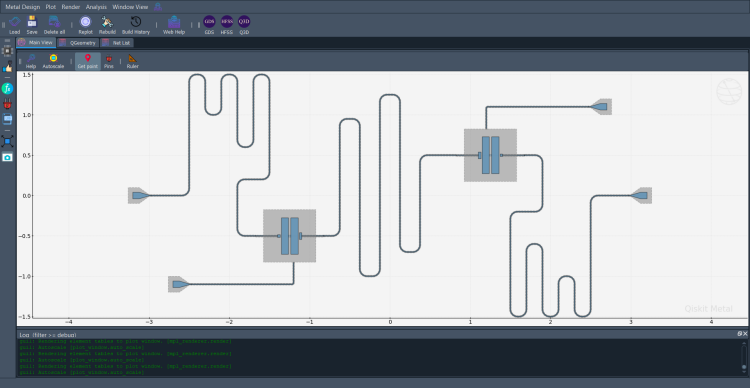

In [40]:
gui.screenshot()

In [41]:
qcomps = design.components

# Set qubit-specific junction inductance and capacitance variable names
qcomps['Q1'].options['hfss_inductance'] = 'Lj1'
qcomps['Q1'].options['hfss_capacitance'] = 'Cj1'
qcomps['Q2'].options['hfss_inductance'] = 'Lj2'
qcomps['Q2'].options['hfss_capacitance'] = 'Cj2'

print("✓ Q1 junction: Lj1, Cj1")
print("✓ Q2 junction: Lj2, Cj2")

# Rebuild GUI to propagate changes to junction table
gui.rebuild()
gui.autoscale()

print("✓ Design rebuilt and autoscaled")

✓ Q1 junction: Lj1, Cj1
✓ Q2 junction: Lj2, Cj2
✓ Design rebuilt and autoscaled


In [42]:
junc_table = design.qgeometry.tables['junction']
print("\nJunction table configuration:")
print(junc_table[['component', 'hfss_inductance', 'hfss_capacitance']])


Junction table configuration:
  component hfss_inductance hfss_capacitance
0         1             Lj1              Cj1
1         2             Lj2              Cj2


In [43]:
from qiskit_metal.renderers.renderer_ansys.hfss_renderer import QHFSSRenderer
renderer = QHFSSRenderer(design)

INFO 05:21PM [connect_project]: Connecting to Ansys Desktop API...
INFO 05:21PM [load_ansys_project]: 	Opened Ansys App
INFO 05:21PM [load_ansys_project]: 	Opened Ansys Desktop v2022.1.0
INFO 05:21PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/veera/OneDrive/Documents/Ansoft/
	Project:   Project151
INFO 05:21PM [connect_design]: No active design found (or error getting active design).
INFO 05:21PM [connect]: 	 Connected to project "Project151". No design detected


In [44]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_qb = EPRanalysis(design, "hfss")

In [45]:
em_p = eig_qb.sim.setup

# Setup name
em_p.name = 'Q1_Q2_Eigenmode_3Modes'

# Frequency range
em_p.min_freq_ghz = 4.0
em_p.max_freq_ghz = None  # Let HFSS calculate

# Modes to solve
em_p.n_modes = 3

# Convergence parameters (IMPORTANT for accurate results)
em_p.max_passes = 20        # More aggressive meshing
em_p.max_delta_f = 0.5     # Tighter frequency convergence
em_p.min_converged = 5      # Require 3 consecutive converged passes
em_p.max_mesh_elements = None
em_p.pct_refinement = 35
em_p.basis_order = 1

In [46]:
em_p.vars = Dict({
    'Lj1': '15.5 nH',
    'Cj1': '0.25 fF',
    'Lj2': '14.3 nH',
    'Cj2': '0.05 fF'
})

print("\nJunction Parameters:")
for var_name, var_value in em_p.vars.items():
    print(f"  {var_name} = {var_value}")


Junction Parameters:
  Lj1 = 15.5 nH
  Cj1 = 0.25 fF
  Lj2 = 14.3 nH
  Cj2 = 0.05 fF


In [47]:
eig_qb.setup.junctions = {}

# Add junctions with correct naming (jj1, jj2 - NOT Q1, Q2)
eig_qb.add_junction(
    'jj1',          # Junction ID (must be 'jj1', not 'Q1')
    'Lj1', 'Cj1',   # Variable names
    rect='JJ_rect_Lj_Q1_rect_jj',
    line='JJ_Lj_Q1_rect_jj_'
)

eig_qb.add_junction(
    'jj2',          # Junction ID (must be 'jj2', not 'Q2')
    'Lj2', 'Cj2',   # Variable names
    rect='JJ_rect_Lj_Q2_rect_jj',
    line='JJ_Lj_Q2_rect_jj_'
)
eig_qb.setup.sweep_variable = 'Lj1'
print("\nJunction configuration:")
print(eig_qb.setup.junctions)


Junction configuration:
{'jj1': {'Lj_variable': 'Lj1', 'Cj_variable': 'Cj1', 'rect': 'JJ_rect_Lj_Q1_rect_jj', 'line': 'JJ_Lj_Q1_rect_jj_'}, 'jj2': {'Lj_variable': 'Lj2', 'Cj_variable': 'Cj2', 'rect': 'JJ_rect_Lj_Q2_rect_jj', 'line': 'JJ_Lj_Q2_rect_jj_'}}


In [49]:
all_comps = list(design.components.keys())
eig_qb.sim.run(
    name='Q1_Q2_lineQ3',
    components= ['Q1','Q2','line_Q3'],
    open_terminations=[]
)

INFO 07:05PM [connect_design]: 	Opened active design
	Design:    Q1_Q2_lineQ3_hfss [Solution type: Eigenmode]
INFO 07:06PM [get_setup]: 	Opened setup `Q1_Q2_Eigenmode_3Modes`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 07:06PM [analyze]: Analyzing setup Q1_Q2_Eigenmode_3Modes
07:46PM 29s INFO [get_f_convergence]: Saved convergences to C:\Users\veera\hfss_eig_f_convergence.csv


In [50]:
eig_qb.run_epr()

Design "Q1_Q2_lineQ3_hfss" info:
	# eigenmodes    3
	# variations    1
Design "Q1_Q2_lineQ3_hfss" info:
	# eigenmodes    3
	# variations    1


  options=pd.Series(get_instance_vars(self.options)),




        energy_elec_all       = 1.46400483056279e-24
        energy_elec_substrate = 1.34908865215284e-24
        EPR of substrate = 92.2%

        energy_mag    = 1.81650719215198e-26
        energy_mag % of energy_elec_all  = 1.2%
        

Variation 0  [1/1]


  Ljs = pd.Series({})

  Cjs = pd.Series({})

  _Om = pd.Series({})




  Mode 0 at 4.95 GHz   [1/3]
    Calculating ℰ_magnetic,ℰ_electric


...

###### Numerical diagonalization

Lj1,15.5
0,4646.68
1,4858.03
2,5602.30


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0       1     2
Lj1                         
15.5 0  327.23   -0.16  2.12
     1   -0.16  326.27  3.26
     2    2.12    3.26  0.02